In [141]:
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

In [142]:
#import required fastai libraries
from fastai.vision.all import *
from fastbook import *

matplotlib.rc('image', cmap='Greys')

In [144]:
path = untar_data(URLs.MNIST_SAMPLE)

In [145]:
#Download the MNIST sample dataset and get file paths for training images
Path.BASE_PATH = path

In [146]:
path.ls()

[Path('valid'), Path('train'), Path('labels.csv')]

In [147]:
(path/'train').ls()

[Path('train/7'), Path('train/3')]

In [8]:
threes = (path/'train'/'3').ls().sorted()
sevens = (path/'train'/'7').ls().sorted()
threes

(#6131) [Path('train/3/10.png'), Path('train/3/10000.png'), Path('train/3/10011.png'), Path('train/3/10031.png'), Path('train/3/10034.png'), Path('train/3/10042.png'), Path('train/3/10052.png'), Path('train/3/1007.png'), Path('train/3/10074.png'), Path('train/3/10091.png'), Path('train/3/10093.png'), Path('train/3/10097.png'), Path('train/3/10099.png'), Path('train/3/10116.png'), Path('train/3/10125.png'), Path('train/3/10137.png'), Path('train/3/10141.png'), Path('train/3/10144.png'), Path('train/3/10155.png'), Path('train/3/10161.png'), Path('train/3/10206.png'), Path('train/3/1021.png'), Path('train/3/10210.png'), Path('train/3/10214.png'), Path('train/3/10238.png'), Path('train/3/10260.png'), Path('train/3/10278.png'), Path('train/3/10282.png'), Path('train/3/10314.png'), Path('train/3/10322.png'), Path('train/3/10328.png'), Path('train/3/10329.png'), Path('train/3/10330.png'), Path('train/3/10349.png'), Path('train/3/1035.png'), Path('train/3/10360.png'), Path('train/3/10369.png')

In [148]:
#open a sample image from the training set to display it
im3_path = threes[1]
im3 = Image.open(im3_path)
im3

In [149]:
array(im3)[4:10,4:10]

array([[  0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,  29],
       [  0,   0,   0,  48, 166, 224],
       [  0,  93, 244, 249, 253, 187],
       [  0, 107, 253, 253, 230,  48],
       [  0,   3,  20,  20,  15,   0]], dtype=uint8)

In [150]:
tensor(im3)[4:10,4:10]

tensor([[  0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,  29],
        [  0,   0,   0,  48, 166, 224],
        [  0,  93, 244, 249, 253, 187],
        [  0, 107, 253, 253, 230,  48],
        [  0,   3,  20,  20,  15,   0]], dtype=torch.uint8)

In [151]:
# Convert the image to a tensor and display a slice of pixel values
# This shows how images are stored as values between 0 and 255
im3_t = tensor(im3)
df = pd.DataFrame(im3_t[4:15,4:22])
df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Greys')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,29,150,195,254,255,254,176,193,150,96,0,0,0
2,0,0,0,48,166,224,253,253,234,196,253,253,253,253,233,0,0,0
3,0,93,244,249,253,187,46,10,8,4,10,194,253,253,233,0,0,0
4,0,107,253,253,230,48,0,0,0,0,0,192,253,253,156,0,0,0
5,0,3,20,20,15,0,0,0,0,0,43,224,253,245,74,0,0,0
6,0,0,0,0,0,0,0,0,0,0,249,253,245,126,0,0,0,0
7,0,0,0,0,0,0,0,14,101,223,253,248,124,0,0,0,0,0
8,0,0,0,0,0,11,166,239,253,253,253,187,30,0,0,0,0,0
9,0,0,0,0,0,16,248,250,253,253,253,253,232,213,111,2,0,0


In [152]:
# Prepare training data
# Stack all training images into tensors and normalize pixel values to 0-1 range
stacked_threes = torch.stack([tensor(Image.open(o)) for o in threes]).float()/255
stacked_sevens = torch.stack([tensor(Image.open(o)) for o in sevens]).float()/255

# Flatten each 28x28 image into a vector of 784 pixels and combine into one dataset
train_x = torch.cat([stacked_threes, stacked_sevens]).view(-1, 28*28)

# Create labels: 1 for threes, 0 for sevens
train_y = tensor([1]*len(threes) + [0]*len(sevens)).unsqueeze(1)

# Pair each image with its label
dset = list(zip(train_x, train_y))

In [153]:
# Prepare validation data using the same process as training data
valid_3_tens = torch.stack([tensor(Image.open(o))
                for o in (path/'valid'/'3').ls()]).float()/255
valid_7_tens = torch.stack([tensor(Image.open(o))
                for o in (path/'valid'/'7').ls()]).float()/255

# Flatten and combine validation images and labels
valid_x = torch.cat([valid_3_tens, valid_7_tens]).view(-1, 28*28)
valid_y = tensor([1]*len(valid_3_tens) + [0]*len(valid_7_tens)).unsqueeze(1)
valid_dset = list(zip(valid_x, valid_y))

In [154]:
# Initialize random weights and bias for the model
def init_params(size, std=1.0):
    return (torch.randn(size)*std).requires_grad_()

weights = init_params((28*28,1))
bias = init_params(1)

In [155]:
# Define a linear model using matrix multiplication
def linear1(xb): return xb@weights + bias

# Define loss function using sigmoid to keep predictions between 0 and 1
def mnist_loss(predictions, targets):
    predictions = predictions.sigmoid()
    return torch.where(targets==1, 1-predictions, predictions).mean()

In [156]:
# Create dataloaders to feed data in batches during training
dl = DataLoader(dset, batch_size=256)
valid_dl = DataLoader(valid_dset, batch_size=256)

In [158]:
# Calculate gradients by running a batch through the model and computing loss
def calc_grad(xb, yb, model):
    preds = model(xb)
    loss = mnist_loss(preds, yb)
    loss.backward()

# Update weights for one full pass through the training data
def train_epoch(model, lr, params):
    for xb,yb in dl:
        calc_grad(xb, yb, model)
        for p in params:
            p.data -= p.grad*lr
            p.grad.zero_()

# Calculate accuracy for one batch of predictions
def batch_accuracy(xb, yb):
    preds = xb.sigmoid()
    correct = (preds>0.5) == yb
    return correct.float().mean()

# Calculate average accuracy across all validation batches
def validate_epoch(model):
    accs = [batch_accuracy(model(xb), yb) for xb,yb in valid_dl]
    return round(torch.stack(accs).mean().item(), 4)

In [159]:
# Train the model for 20 epochs and print accuracy after each epoch
lr = 1.
params = weights, bias

for i in range(20):
    train_epoch(linear1, lr, params)
    print(validate_epoch(linear1), end=' ')

0.4922 0.4937 0.4937 0.4951 0.4971 0.5045 0.5411 0.6072 0.8305 0.9233 0.9447 0.9565 0.9614 0.9643 0.9657 0.9687 0.9716 0.9721 0.9731 0.9741 

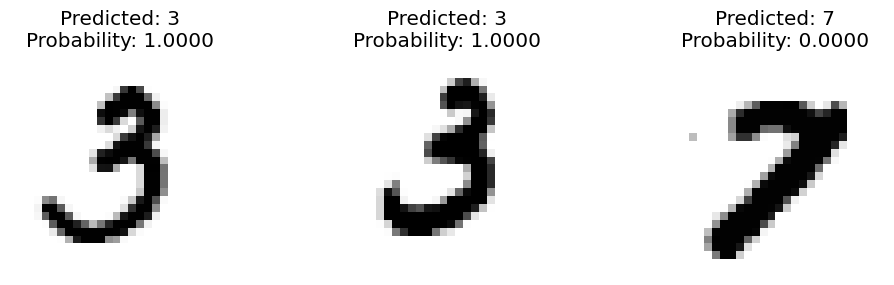

In [160]:
# Pick 3 sample images from the validation set and make predictions
# First image - should be a 3
sample1 = valid_3_tens[0]
sample2 = valid_3_tens[1]
sample3 = valid_7_tens[0]

# Display each image and print its prediction
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for i, (sample, ax) in enumerate(zip([sample1, sample2, sample3], axes)):
    # Run image through model
    pred = linear1(sample.view(1, -1))
    pred_prob = pred.sigmoid().item()
    predicted_class = "3" if pred_prob > 0.5 else "7"

    # Show image with prediction
    ax.imshow(sample, cmap='Greys')
    ax.set_title(f'Predicted: {predicted_class}\nProbability: {pred_prob:.4f}')
    ax.axis('off')

plt.tight_layout()
plt.show()

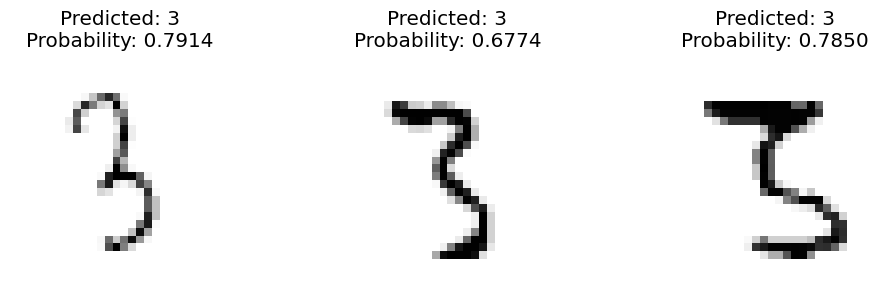

In [162]:
# Find 3 images the model is less certain about
# These are cases where the probability falls between 0.4 and 0.9
uncertain_images = []
uncertain_probs = []

for i in range(len(valid_3_tens)):
    sample = valid_3_tens[i]
    pred = linear1(sample.view(1, -1))
    pred_prob = pred.sigmoid().item()

    if 0.4 < pred_prob < 0.9:
        uncertain_images.append(sample)
        uncertain_probs.append(pred_prob)

    if len(uncertain_images) == 3:
        break

# Display the 3 uncertain images with their probabilities
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for i, (sample, prob, ax) in enumerate(zip(uncertain_images, uncertain_probs, axes)):
    predicted_class = "3" if prob > 0.5 else "7"
    ax.imshow(sample, cmap='Greys')
    ax.set_title(f'Predicted: {predicted_class}\nProbability: {prob:.4f}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Questionnaire

1. How is a grayscale image represented on a computer? How about a color image?
1. How are the files and folders in the `MNIST_SAMPLE` dataset structured? Why?
1. Explain how the "pixel similarity" approach to classifying digits works.
1. What is a list comprehension? Create one now that selects odd numbers from a list and doubles them.
1. What is a "rank-3 tensor"?
1. What is the difference between tensor rank and shape? How do you get the rank from the shape?
1. What are RMSE and L1 norm?
1. How can you apply a calculation on thousands of numbers at once, many thousands of times faster than a Python loop?
1. Create a 3×3 tensor or array containing the numbers from 1 to 9. Double it. Select the bottom-right four numbers.
1. What is broadcasting?
1. Are metrics generally calculated using the training set, or the validation set? Why?
1. What is SGD?
1. Why does SGD use mini-batches?
1. What are the seven steps in SGD for machine learning?
1. How do we initialize the weights in a model?
1. What is "loss"?
1. Why can't we always use a high learning rate?
1. What is a "gradient"?
1. Do you need to know how to calculate gradients yourself?
1. Why can't we use accuracy as a loss function?
1. Draw the sigmoid function. What is special about its shape?
1. What is the difference between a loss function and a metric?
1. What is the function to calculate new weights using a learning rate?
1. What does the `DataLoader` class do?
1. Write pseudocode showing the basic steps taken in each epoch for SGD.
1. Create a function that, if passed two arguments `[1,2,3,4]` and `'abcd'`, returns `[(1, 'a'), (2, 'b'), (3, 'c'), (4, 'd')]`. What is special about that output data structure?
1. What does `view` do in PyTorch?
1. What are the "bias" parameters in a neural network? Why do we need them?
1. What does the `@` operator do in Python?
1. What does the `backward` method do?
1. Why do we have to zero the gradients?
1. What information do we have to pass to `Learner`?
1. Show Python or pseudocode for the basic steps of a training loop.
1. What is "ReLU"? Draw a plot of it for values from `-2` to `+2`.
1. What is an "activation function"?
1. What's the difference between `F.relu` and `nn.ReLU`?
1. The universal approximation theorem shows that any function can be approximated as closely as needed using just one nonlinearity. So why do we normally use more?

# Responses
1.   A grayscale image is represented as a matrix of pixels where each pixel is represented by a value between 0 to 255 showing intensity levels ranging from white to black respectively. Values in between represent different shades of gray. Color images on the other hand are represented by pixels with 3 dimensions. Each number represents the intensity of Red, Green, and Blue (RGB). Each value is also between 0 and 255 and combining different values creates different colors. (Howard & Gugger, 2020)

2.   The MNIST_SAMPLE dataset is structured as folders and subfolders. At the top level there are two folders, train and valid, which separate the training and validation data. Inside each of those folders there are subfolders named after the label they contain (for example 3 and 7). Each subfolder contains image files of that digit.

Each image itself is structured as a grid of rows and columns of pixels, forming a 28x28 matrix. This means each image has 28 rows and 28 columns giving a total of 784 pixels.

3. The pixel similarity approach works by calculating an "ideal" version of each label using the training data. For each label, it computes the average pixel value across all training images of that label. This creates an average image that represents what a typical target looks like.

To classify a new image, the approach measures how similar it is to each of the ideal average images by calculating the distance between the pixel values. Two common distance measures are used:

*   Mean Absolute Difference (L1 norm): takes the average of the absolute differences between pixel values
*   Root Mean Squared Error (L2 norm): takes the square root of the average of the squared differences

The new image is then assigned to the label whose ideal image it is closest to. For example if a new image is more similar to the ideal target 3 than the ideal target 7 it gets classified as a 3 (Howard & Gugger, 2020).

4. A list comprehension is a concise way to create a list in Python using a single line of code. It combines a loop and an optional condition into one expression.


In [163]:
numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
result = [x*2 for x in numbers if x % 2 != 0]
print(result)

[2, 6, 10, 14, 18]


5. A tensor is a multi-dimensional array of numbers. The rank of a tensor refers to the number of dimensions it has.

Rank 0 = a single number (scalar) e.g. 5
Rank 1 = a list of numbers (vector) e.g. [1, 2, 3]
Rank 2 = a table of numbers (matrix) e.g. a 28x28 image
Rank 3 = a collection of matrices e.g. a stack of multiple images

So a rank-3 tensor has 3 dimensions. In the context of MNIST a rank-3 tensor would be a stack of multiple images where:

First dimension = number of images
Second dimension = rows of pixels
Third dimension = columns of pixels

For example our stacked_threes tensor with shape (6131, 28, 28) is a rank-3 tensor.

6. As described in the previous response, rank refers to the number of dimensions a tensor has and shape refers to the size of each dimension.
The difference is that rank is a single number telling you how many dimensions there are, while shape is a tuple telling you the size of each of those dimensions. For example a tensor with shape (6131, 28, 28) has a rank of 3 because there are 3 numbers in the shape.
You can get the rank from the shape simply by counting the number of elements in the shape tuple. In PyTorch this can be done using len(tensor.shape) or tensor.ndim.

7. L1 norm (Mean Absolute Difference): A way of measuring the distance between two sets of values by taking the average of the absolute differences between each pair of values. It is called L1 because it uses absolute values.

RMSE (Root Mean Squared Error): Another way of measuring distance between two sets of values. It works by squaring the differences between each pair of values, taking the mean of those squared differences and then taking the square root. It is called L2 norm in mathematics.

The key difference between the two is that RMSE penalizes larger mistakes more heavily than L1 norm because it squares the differences. This means a prediction that is very far off will have a much larger impact on RMSE than on L1 norm.

In the context of MNIST both measures were used to calculate how different a test image was from the ideal average image of each label (Howard & Gugger, 2020).

8. This can be done using vectorized operations in PyTorch or NumPy. Instead of using a Python loop to process one number at a time, these libraries allow you to perform calculations on entire arrays or tensors at once.

This is much faster because:


*   The operations are written in C or CUDA which are much faster than Python.
*   When using a GPU the calculations can be done in parallel across thousands of cores at the same time.
*   Python loops are slow because Python has to process each number one at a time.

9.






In [165]:
#9. Create a 3x3 tensor with numbers 1 to 9
t = tensor([[1,2,3],
            [4,5,6],
            [7,8,9]])

# Double it
t = t * 2
print(t)

# Select the bottom-right four numbers
t[1:,1:]

tensor([[ 2,  4,  6],
        [ 8, 10, 12],
        [14, 16, 18]])


tensor([[10, 12],
        [16, 18]])

10. Broadcasting is a feature in PyTorch and NumPy that allows operations to be performed between tensors of different shapes or sizes. Instead of requiring both tensors to be the same size, PyTorch automatically expands the smaller tensor to match the shape of the larger one without actually copying the data in memory.
For example in our MNIST notebook we used broadcasting when we subtracted the ideal average image from all validation images at once. The average image had shape (28, 28) while the validation set had shape (1010, 28, 28). PyTorch automatically treated the average image as if it were repeated 1010 times to match the validation set shape.

11. Metrics are generally calculated using the validation set not the training set.

The reason for this is that we want to measure how well the model performs on data it has never seen before. If we calculated metrics on the training set we would only know how well the model has memorized the training data which is not a good indicator of how it will perform in the real world.

In the MNIST notebook for example we calculated accuracy on the validation set using validate_epoch() to get a true measure of how well our model was learning to distinguish between the labels.

12. SGD stands for Stochastic Gradient Descent. It is the method used to update the parameters of a model during training to minimize the loss function. The word stochastic means random and refers to the fact that we use random mini-batches of data rather than the entire dataset at each step. This makes the process faster and often leads to better results than using the full dataset at each step.

13. SGD uses mini-batches because using the full dataset at once would be too slow and memory intensive, while using a single item at a time would produce noisy and unreliable gradients. Mini-batches provide a good balance between speed, memory efficiency and gradient accuracy. They also work well with GPUs which perform best when processing multiple items at once.

14.

*   Initialize the parameters (weights and bias) with random values
*   Predict by running the inputs through the model using the current parameters
*   Calculate the loss to measure how wrong the predictions are
*   Calculate the gradients to determine how much each parameter contributed to the loss
*   Step the parameters by updating them in the direction that reduces the loss using the learning rate
*   Repeat steps 2 to 5 for each mini-batch until the model performs well
*   Stop training when the model has reached a satisfactory level of performance

15. The weights in a model are initialized with random values drawn from a normal distribution. Although it may seem strange to start with random values, it works because the SGD process will gradually improve the weights over time through training. The key requirement is that the weights are different from each other at the start so that each parameter can learn something different during training.

16. Loss is a number that measures how wrong the model's predictions are compared to the actual targets. A lower loss means the model is performing better and a higher loss means the model is performing worse. During training the goal is to minimize the loss by updating the model's parameters using SGD. In our MNIST notebook we used the mnist_loss function which measured how far the model's predictions were from the correct labels.

17. We cannot always use a high learning rate because it can cause the model to overshoot the optimal parameters during training. If the learning rate is too high the model may jump past the minimum loss value and actually get worse instead of better. In extreme cases the loss can become unstable and diverge completely making the model unusable. A good learning rate needs to be small enough that the model takes careful steps toward the minimum loss but large enough that training does not take too long.

18. A gradient is a measure of how much the loss changes when we make a small change to a parameter. It tells us both the direction and the size of the change needed to reduce the loss. A positive gradient means increasing the parameter will increase the loss, while a negative gradient means increasing the parameter will decrease the loss. In PyTorch gradients are calculated automatically using the backward() method which makes it easy to update the parameters during training.

19. PyTorch automatically calculates gradients using the backward() method. This is one of the most powerful features of PyTorch as it handles all the complex calculus behind the scenes. All a data scientist needs to understand is that gradients tell you how to adjust the parameters to reduce the loss and PyTorch takes care of the actual calculations.

20. We cannot use accuracy as a loss function because it does not change smoothly with small changes in the model parameters. Accuracy only changes when a prediction flips from one class to another, meaning that most small adjustments to the weights will produce no change in accuracy at all. This makes the gradient either zero or undefined almost everywhere which gives SGD nothing useful to work with. Instead we use a loss function like mnist_loss which changes smoothly and continuously with small changes in the parameters giving SGD meaningful gradients to work with.

21. The sigmoid function has an S-shaped curve as shown below:








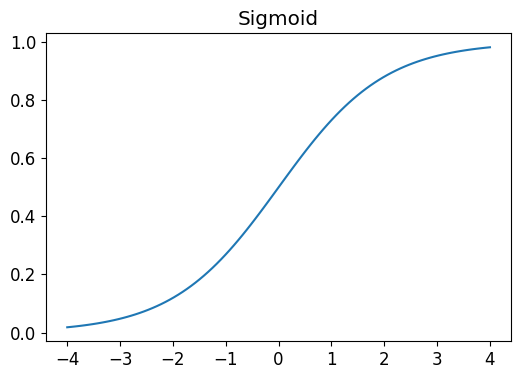

In [166]:
# Plot the sigmoid function
plot_function(torch.sigmoid, title='Sigmoid', min=-4, max=4)

What makes it special is that it takes any input value, whether positive or negative, and squashes it to an output value between 0 and 1. This makes it very useful because:

*   It always produces a value between 0 and 1 which can be interpreted as a probability
*   It is smooth and continuous which means it has a well defined gradient everywhere
*   For very large positive inputs it approaches 1 and for very large negative inputs it approaches 0

In our MNIST notebook we used the sigmoid function in our loss function to ensure that predictions were always between 0 and 1 before calculating the loss (Howard & Gugger, 2020).

22. A loss function and a metric both measure model performance but they serve different purposes. A loss function is used to drive the training process and must be smooth and continuous so that SGD can calculate meaningful gradients. A metric on the other hand is used to measure how well the model is performing in a way that is meaningful to humans such as accuracy. Metrics do not need to be smooth or differentiable since they are only used for reporting and not for training. In our MNIST notebook mnist_loss was our loss function while accuracy was our metric.

23. The function to calculate new weights using a learning rate is:
new_weight = weight - gradient × learning_rate

This formula updates each weight by subtracting the gradient multiplied by the learning rate. The gradient tells us the direction and size of the change needed and the learning rate controls how big a step we take. In our MNIST notebook this was implemented as:

p.data -= p.grad * lr

24. The DataLoader class takes a dataset and automatically handles splitting it into mini-batches for training. It also shuffles the data at the start of each epoch to ensure the model sees the data in a different order each time. This is important because it helps the model learn more general patterns rather than memorizing the order of the training data. In our MNIST notebook we used DataLoader with a batch size of 256 meaning the model processed 256 images at a time during training.

25. For each epoch:
    For each mini-batch in training data:
        1. Calculate predictions using current parameters
        2. Calculate loss by comparing predictions to targets
        3. Calculate gradients using backward()
        4. Update parameters: parameter = parameter - gradient x learning rate
        5. Reset gradients to zero
    
    Calculate and print validation accuracy

26.

In [167]:
# Create a function that pairs two lists together
def pair_lists(a, b):
    return list(zip(a, b))

# Test it
result = pair_lists([1,2,3,4], 'abcd')
print(result)
# Output: [(1, 'a'), (2, 'b'), (3, 'c'), (4, 'd')]

[(1, 'a'), (2, 'b'), (3, 'c'), (4, 'd')]


The function uses Python's built in zip function to pair elements from both inputs together and returns them as a list of tuples. What is special about the output is that it is a list of tuples where each tuple contains one element from each input. This is the same data structure used by PyTorch datasets where each tuple contains one image and its corresponding label.

27. The view method in PyTorch changes the shape of a tensor without changing its data. It allows you to reorganize the dimensions of a tensor into a new shape as long as the total number of elements remains the same. For example in our MNIST notebook we used view(-1, 28*28) to reshape each 28x28 image into a flat vector of 784 pixels. The -1 is a special parameter that tells PyTorch to automatically calculate the size of that dimension based on the total number of elements.

28. Bias parameters are additional values added to the output of each layer in a neural network. They allow the model to shift its predictions up or down independently of the input values. Without bias parameters the model would always produce an output of zero when all inputs are zero which would severely limit what the model can learn. Adding a bias gives the model more flexibility to fit the data. In our MNIST notebook we initialized a bias parameter alongside the weights and added it to the output of our linear function using xb@weights + bias.

29. The @ operator in Python performs matrix multiplication between two tensors or arrays. It multiplies each row of the first matrix by each column of the second matrix and sums the results. In our MNIST notebook we used it in our linear function as xb@weights to multiply each image by the weight parameters. This allowed us to calculate predictions for an entire batch of images at once rather than processing each image individually in a loop.

30. The backward method in PyTorch implements backpropagation. Backpropagation is the process of working backwards through all the calculations that were performed to produce the loss and computing how much each parameter contributed to it. When called on the loss tensor it automatically calculates the gradients of the loss with respect to all model parameters. These gradients are then stored in each parameter's .grad attribute and used to update the parameters during the SGD step. In our MNIST notebook we called loss.backward() after calculating the loss in each mini-batch to get the gradients needed to update the weights and bias

31. We have to zero the gradients after each parameter update because PyTorch accumulates gradients by default. This means that if we do not reset them to zero the gradients from the previous mini-batch will be added to the gradients of the current mini-batch giving us incorrect values. By calling p.grad.zero_() after each update we ensure that the gradients are fresh and only reflect the current mini-batch. In our MNIST notebook this was done inside the training loop after each parameter update.

32. To create a Learner in fastai we need to pass in the following information:

*   DataLoaders - the training and validation data loaders
*   Model - the neural network architecture we want to train
*   Optimization function - the optimizer to use for updating parameters such as SGD
*   Loss function - the function used to measure how wrong the predictions are
*   Metrics - optional functions used to evaluate model performance such as accuracy

In our MNIST notebook we created a Learner by passing in our DataLoaders, a linear model, SGD as the optimizer, mnist_loss as the loss function and batch_accuracy as the metric.

33. For each epoch:
    For each mini-batch in training data:
        1. Calculate predictions using current parameters
        2. Calculate loss by comparing predictions to targets
        3. Calculate gradients using backward()
        4. Update parameters: parameter = parameter - gradient x learning rate
        5. Reset gradients to zero
    
    Calculate and print validation accuracy

34. ReLU stands for Rectified Linear Unit. It is a simple nonlinear activation function that returns 0 for any negative input and returns the input value unchanged for any positive input. In other words it simply removes all negative values and replaces them with zero.
The plot can be drawn with:

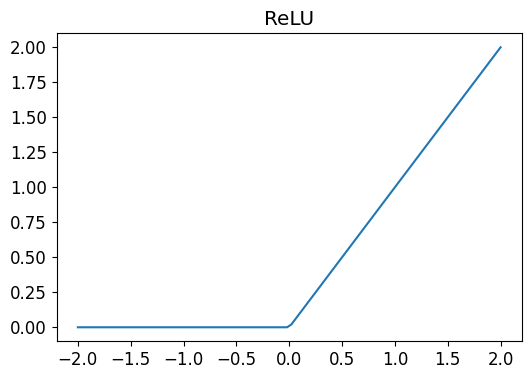

In [169]:
# Plot the ReLU function
plot_function(F.relu, title='ReLU', min=-2, max=2)

ReLU is important in neural networks because it introduces nonlinearity between linear layers which allows the model to learn more complex patterns. Without nonlinear functions like ReLU stacking multiple linear layers would be no different from having a single linear layer.

35. An activation function is a nonlinear function that is applied between linear layers in a neural network. Its purpose is to introduce nonlinearity into the model which allows it to learn more complex patterns that a simple linear model could not capture. Without activation functions stacking multiple linear layers would be mathematically equivalent to having just one linear layer. Common examples of activation functions include ReLU and sigmoid which we used in our MNIST notebook.

36. Both F.relu and nn.ReLU do exactly the same thing which is apply the ReLU activation function. The difference is in how they are used. F.relu is a function that can be called directly on a tensor while nn.ReLU is a class that needs to be instantiated first before it can be used. When using nn.Sequential to build a neural network PyTorch requires us to use the class version nn.ReLU() because Sequential expects modules not functions. In other situations we can use either version as they produce identical results (Howard & Gugger, 2020).

37. Although the universal approximation theorem shows that a single nonlinearity is theoretically sufficient to approximate any function, in practice deeper models with more layers perform much better. The reason is that deeper models can achieve the same level of accuracy with far fewer total parameters than a shallow model with one nonlinearity. This means deeper models are faster to train, require less memory and tend to generalize better to new data. Research has shown that using multiple layers allows each layer to learn increasingly complex and abstract features from the data which leads to better performance in practice (Howard & Gugger, 2020).

# References

Howard, J., & Gugger, S. (2020). Deep learning for coders with fastai and PyTorch: AI applications without a PhD. GitHub. https://github.com/fastai/fastbook